Predict the next three numbers (revisited 2):
- This example is neither sequence-to-scalar (like ex3) nor sequence-to-vector (like ex4).
- This example is the sequence-to-sequence prediction model that <u>predicts 3-step-ahead numbers for all unrolled time steps (not just the last time step like all previous examples)</u>.

# 1. Prepare the environment

In [1]:
# List all NVIDIA GPUs as available in this computer (or Colab's session)
!nvidia-smi -L

GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-c3bb9ccc-e456-c7bb-681f-114a2b479214)


In [2]:
import sys
print( f"Python {sys.version}\n" )

import numpy as np
print( f"NumPy {np.__version__}\n" )

import matplotlib.pyplot as plt
%matplotlib inline

# https://keras.io/getting_started/
# The backend must be configured before importing Keras, and the backend cannot be changed after the package has been imported.
import os
os.environ["KERAS_BACKEND"] = "torch"  # "jax", "tensorflow"

import keras
print(f"Keras {keras.__version__}")
print(f"|- Keras backend = {keras.backend.backend()}")
print(f"|- Keras backend image data format = {keras.backend.image_data_format()}\n")

import torch
print( f"PyTorch {torch.__version__}" )

# Get all available accelerators such as CUDA, MPS, MTIA, or XPU
num_accelerators = torch.accelerator.device_count()

if (num_accelerators <= 0):
    print("|- No hardware accelerators found. Using CPU only.")
else:
    print(f"|- PyTorch detected {num_accelerators} hardware accelerator(s)")
    print(f"|- PyTorch detected '{torch.accelerator.current_accelerator().type.upper()}' as the current accelerator")

    # Check cuda availability
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        print(f"|- PyTorch detected {num_gpus} CUDA GPU(s):")
    for i in range(num_gpus):
        print(f"   |- CUDA GPU {i}: {torch.cuda.get_device_name(i)}")

Python 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]

NumPy 2.0.2

Keras 3.10.0
|- Keras backend = torch
|- Keras backend image data format = channels_last

PyTorch 2.8.0+cu126
|- PyTorch detected 1 hardware accelerator(s)
|- PyTorch detected 'CUDA' as the current accelerator
|- PyTorch detected 1 CUDA GPU(s):
   |- CUDA GPU 0: NVIDIA A100-SXM4-40GB


In [3]:
# Set fixed seeding values for reproducability during experiments
# Skip this cell if random initialization (with varied results) is needed

# https://keras.io/examples/keras_recipes/reproducibility_recipes/
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
#keras.utils.set_random_seed(1234)

# 2. Create the deep RNN model

Change the last Dense layer so that `Dense(3)` is repeatedly applied to results from all time steps

In [4]:
my_rnn = keras.models.Sequential()
my_rnn.add( keras.layers.Input( shape=(None,1) ) )

# batch_size=None, time_steps=None, input_dim=1
# Output from this layer is (batch_size,units)=(batch_size,10)
my_rnn.add( keras.layers.SimpleRNN( units=20, return_sequences=True ) )
my_rnn.add( keras.layers.SimpleRNN( units=20, return_sequences=True ) )
my_rnn.add( keras.layers.SimpleRNN( units=10, return_sequences=True ) )  # Output predictions of all time steps

# Use the default linear activation
my_rnn.add( keras.layers.TimeDistributed( keras.layers.Dense(3) ) )

my_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, None, 20)       │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, None, 20)       │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, None, 10)       │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, None, 3)        │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,603 (6.26 KB)

 Trainable params: 1,603 (6.26 KB)

 Non-trainable params: 0 (0.00 B)

# 3. Create train/val/test sets

- Generate a 1D time series from `start_val` to `stop_val` with step 2:

In [5]:
start_val , stop_val = -4000 , 2000

# Create raw data
series = np.arange(start_val, stop_val+1, 2)
n_data = series.shape[0]

# Preview
print(f"{type(series)=} , {series.shape=} , {series}")

type(series)=<class 'numpy.ndarray'> , series.shape=(3001,) , [-4000 -3998 -3996 ...  1996  1998  2000]


- <u>Split the data from oldest to newest</u>: first 80% for training, next 10% for validation, last 10% for testing.
- Compute the training statistics (mean and SD) <u>using only the training portion</u>.
- Normalize the entire 1D sequence (z-score) using the training statistics.

In [6]:
# Split ratios
n_train = int(n_data * 0.8)         # 80% train
n_test = int(n_data * 0.1)          # 10% test
n_val = n_data - n_train - n_test   # 10% validation

# Compute training's mean and SD
train_mean = np.mean(series[:n_train])
train_std = np.std(series[:n_train])

# Normalize entire series using training stats
series_norm = (series - train_mean) / train_std
print(f"{type(series_norm)=} , {series_norm.shape=} , {series_norm}")

type(series_norm)=<class 'numpy.ndarray'> , series_norm.shape=(3001,) , [-1.73132927 -1.72988589 -1.72844252 ...  2.59591137  2.59735475
  2.59879812]


- Split the normalized 1D sequence (`series_norm`) into input sequences `X_norm` (each containing `n_input_timesteps`=5 consecutive values) and targets `Y_norm` (each containing the next `n_output_timesteps`=3 values for all time steps). The unnormalized versions (`X` and `Y`) are kept only for reference.
  - RNN_ex2 requires one-step outputs: `X[i]=[2,4,6,8,10] , Y[i]=12`
  - RNN_ex4 requires three-step outputs: `X[i]=[2,4,6,8,10] , Y[i]=[12,14,16]`
  - This example (RNN_ex5) requires three-step outputs for not only the last time step but also all time steps: `X[i]=[2,4,6,8,10] , Y[i]=[[4,6,8], [6,8,10], [8,10,12], [10,12,14], [12,14,16]]`

In [8]:
# Sliding window parameters
n_input_timesteps = 5  # number of timesteps for input sequence
n_output_steps = 3     # number of steps to predict for each input time step

# Generate sliding windows
X, Y = [], []
X_norm, Y_norm = [], []

for i in range(len(series_norm) - n_input_timesteps - n_output_steps + 1):
    # Input sequence
    X.append(series[i:i+n_input_timesteps])
    X_norm.append(series_norm[i:i+n_input_timesteps])

    # Output sequence: for each time step in X, take next 3 steps
    y_seq = []
    for j in range(n_input_timesteps):
        y_seq.append(series[i+j+1 : i+j+1+n_output_steps])
    Y.append(y_seq)

    y_seq_norm = []
    for j in range(n_input_timesteps):
        y_seq_norm.append(series_norm[i+j+1 : i+j+1+n_output_steps])
    Y_norm.append(y_seq_norm)

X = np.array(X)
Y = np.array(Y)
X_norm = np.array(X_norm)
Y_norm = np.array(Y_norm)

# Preview
print(f"{type(X)=} , {X.shape=} , {X[:3]}")
print(f"{type(Y)=} , {Y.shape=} , {Y[:3]}\n")
print(f"{type(X_norm)=} , {X_norm.shape=} , {X_norm[:3]}")
print(f"{type(Y_norm)=} , {Y_norm.shape=} , {Y_norm[:3]}")

type(X)=<class 'numpy.ndarray'> , X.shape=(2994, 5) , [[-4000 -3998 -3996 -3994 -3992]
 [-3998 -3996 -3994 -3992 -3990]
 [-3996 -3994 -3992 -3990 -3988]]
type(Y)=<class 'numpy.ndarray'> , Y.shape=(2994, 5, 3) , [[[-3998 -3996 -3994]
  [-3996 -3994 -3992]
  [-3994 -3992 -3990]
  [-3992 -3990 -3988]
  [-3990 -3988 -3986]]

 [[-3996 -3994 -3992]
  [-3994 -3992 -3990]
  [-3992 -3990 -3988]
  [-3990 -3988 -3986]
  [-3988 -3986 -3984]]

 [[-3994 -3992 -3990]
  [-3992 -3990 -3988]
  [-3990 -3988 -3986]
  [-3988 -3986 -3984]
  [-3986 -3984 -3982]]]

type(X_norm)=<class 'numpy.ndarray'> , X_norm.shape=(2994, 5) , [[-1.73132927 -1.72988589 -1.72844252 -1.72699914 -1.72555577]
 [-1.72988589 -1.72844252 -1.72699914 -1.72555577 -1.72411239]
 [-1.72844252 -1.72699914 -1.72555577 -1.72411239 -1.72266902]]
type(Y_norm)=<class 'numpy.ndarray'> , Y_norm.shape=(2994, 5, 3) , [[[-1.72988589 -1.72844252 -1.72699914]
  [-1.72844252 -1.72699914 -1.72555577]
  [-1.72699914 -1.72555577 -1.72411239]
  [-1.72555

- Divide `X_norm` and `Y_norm` into training, validation, and test sets. The unnormalized versions are kept only for reference.
- Reshape `X_norm` into `(batch_size, time_steps, input_dim)` as required by the SimpleRNN layer

In [9]:
# Split indices
train_end = n_train - n_input_timesteps
val_end = train_end + n_val

# Split into train/val/test
x_train = X[:train_end].reshape(-1, n_input_timesteps, 1)
y_train = Y[:train_end]
x_train_norm = X_norm[:train_end].reshape(-1, n_input_timesteps, 1)
y_train_norm = Y_norm[:train_end]

x_val = X[train_end:val_end].reshape(-1, n_input_timesteps, 1)
y_val = Y[train_end:val_end]
x_val_norm = X_norm[train_end:val_end].reshape(-1, n_input_timesteps, 1)
y_val_norm = Y_norm[train_end:val_end]

x_test = X[val_end:].reshape(-1, n_input_timesteps, 1)
y_test = Y[val_end:]
x_test_norm = X_norm[val_end:].reshape(-1, n_input_timesteps, 1)
y_test_norm = Y_norm[val_end:]

# Preview shapes
print(f"x_train shape: {x_train.shape}, y_train_norm shape: {y_train.shape}")
print(f"x_val shape: {x_val.shape}, y_val_norm shape: {y_val.shape}")
print(f"x_test shape: {x_test.shape}, y_test_norm shape: {y_test.shape}")
print(f"x_train_norm shape: {x_train_norm.shape}, y_train_norm shape: {y_train_norm.shape}")
print(f"x_val_norm shape: {x_val_norm.shape}, y_val_norm shape: {y_val_norm.shape}")
print(f"x_test_norm shape: {x_test_norm.shape}, y_test_norm shape: {y_test_norm.shape}")

# Preview first sample
print("\nFirst x_train sample:", x_train[0].ravel())
print("First y_train sample:", y_train[0])
print("First x_train_norm sample:", x_train_norm[0].ravel())
print("First y_train_norm sample:", y_train_norm[0])

x_train shape: (2395, 5, 1), y_train_norm shape: (2395, 5, 3)
x_val shape: (301, 5, 1), y_val_norm shape: (301, 5, 3)
x_test shape: (298, 5, 1), y_test_norm shape: (298, 5, 3)
x_train_norm shape: (2395, 5, 1), y_train_norm shape: (2395, 5, 3)
x_val_norm shape: (301, 5, 1), y_val_norm shape: (301, 5, 3)
x_test_norm shape: (298, 5, 1), y_test_norm shape: (298, 5, 3)

First x_train sample: [-4000 -3998 -3996 -3994 -3992]
First y_train sample: [[-3998 -3996 -3994]
 [-3996 -3994 -3992]
 [-3994 -3992 -3990]
 [-3992 -3990 -3988]
 [-3990 -3988 -3986]]
First x_train_norm sample: [-1.73132927 -1.72988589 -1.72844252 -1.72699914 -1.72555577]
First y_train_norm sample: [[-1.72988589 -1.72844252 -1.72699914]
 [-1.72844252 -1.72699914 -1.72555577]
 [-1.72699914 -1.72555577 -1.72411239]
 [-1.72555577 -1.72411239 -1.72266902]
 [-1.72411239 -1.72266902 -1.72122564]]


# 4. Compile and train the model

- During training, we use losses computed from all time steps.
- **BUT**, during evaluation, we only use loss computed from the last time step.

In [17]:
# Create a custom metric to judge the performance of our model
# Instead of using the backend (PyTorch) operations to do tensor computation like ex1-4, this example uses keras.ops

@keras.saving.register_keras_serializable()
def laststep_mae( y_true, y_pred):
    return keras.ops.mean( keras.ops.abs(y_pred[ :, -1] - y_true[ :, -1]), axis=-1)

@keras.saving.register_keras_serializable()
def laststep_mae_denorm( y_true, y_pred):
    # y_true and y_pred are normalized
    y_true_denorm = (y_true * train_std) + train_mean
    y_pred_denorm = (y_pred * train_std) + train_mean
    return keras.ops.mean( keras.ops.abs(y_pred_denorm[ :, -1] - y_true_denorm[ :, -1]), axis=-1)

adam = keras.optimizers.Adam(learning_rate=0.001)
my_rnn.compile( loss="mse", optimizer=adam, metrics=[laststep_mae, laststep_mae_denorm] )

In [11]:
checkpoint_filepath = "RNN_ex5_bestmodel_epoch{epoch:03d}.keras"
model_checkpoint_callback = keras.callbacks.ModelCheckpoint( filepath=checkpoint_filepath,
                                                                save_weights_only=False,
                                                                monitor='val_loss',
                                                                mode='min',
                                                                save_best_only=True)

In [12]:
hist = my_rnn.fit ( x_train_norm, y_train_norm,
                    validation_data=(x_val_norm,y_val_norm),
                    batch_size=64, epochs=300,
                    callbacks=[model_checkpoint_callback] )

Epoch 1/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - laststep_mae: 0.9397 - laststep_mae_denorm: 1302.0282 - loss: 1.4605 - val_laststep_mae: 0.7194 - val_laststep_mae_denorm: 996.8861 - val_loss: 1.4355
Epoch 2/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - laststep_mae: 0.3120 - laststep_mae_denorm: 432.3250 - loss: 0.2797 - val_laststep_mae: 0.7651 - val_laststep_mae_denorm: 1060.1442 - val_loss: 0.9307
Epoch 3/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - laststep_mae: 0.1919 - laststep_mae_denorm: 265.9029 - loss: 0.1324 - val_laststep_mae: 0.6167 - val_laststep_mae_denorm: 854.5425 - val_loss: 0.5362
Epoch 4/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - laststep_mae: 0.1205 - laststep_mae_denorm: 166.9853 - loss: 0.0656 - val_laststep_mae: 0.4705 - val_laststep_mae_denorm: 651.9208 - val_loss: 0.3362
Epoch 5/300
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - laststep_mae: 0.0809 - laststep_mae_denorm: 112.0376 - loss: 0.0343 - val_laststep_mae: 0.3916 - val_laststep_mae_denorm: 542.60

In [13]:
hist.history.keys()

dict_keys(['laststep_mae', 'laststep_mae_denorm', 'loss', 'val_laststep_mae', 'val_laststep_mae_denorm', 'val_loss'])

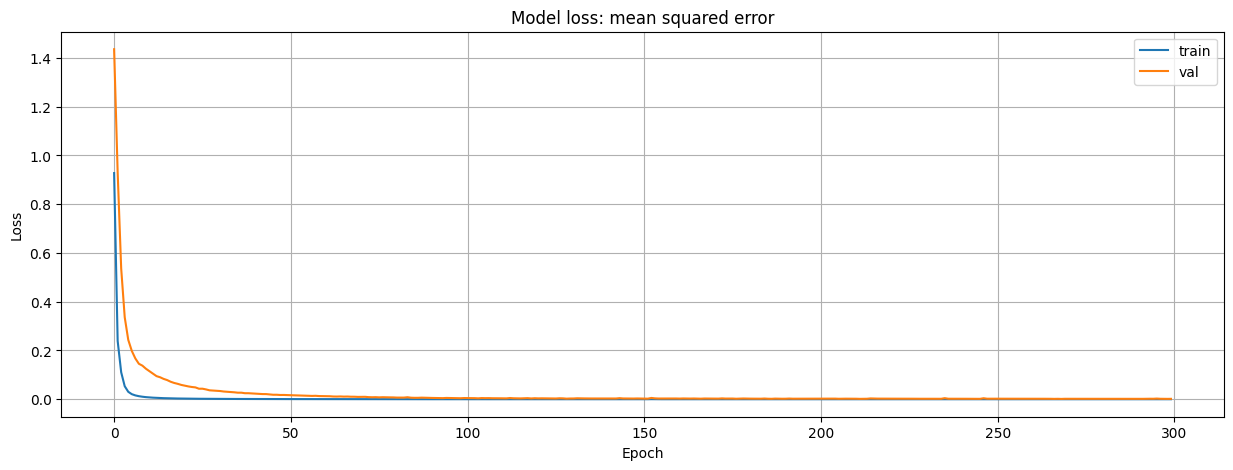

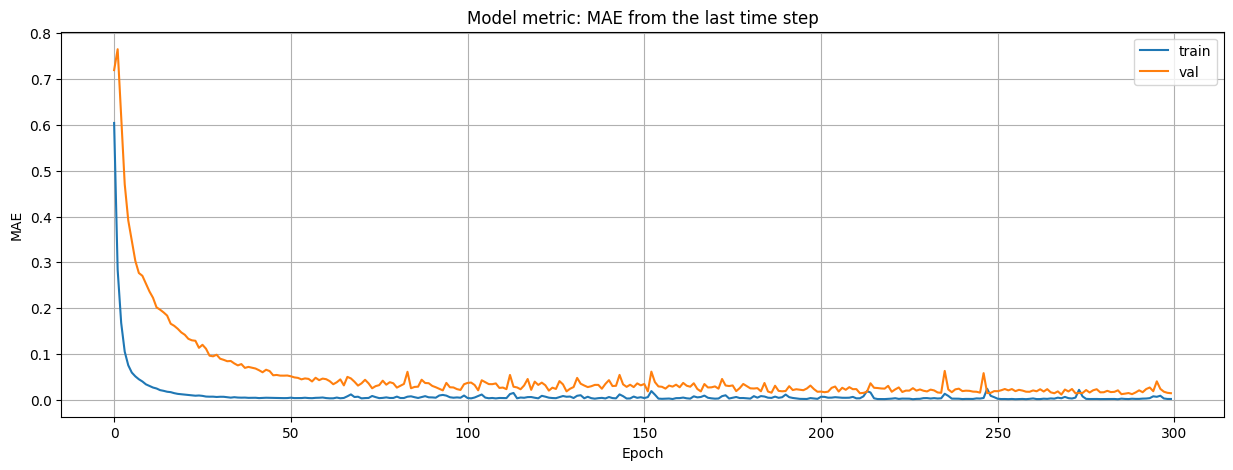

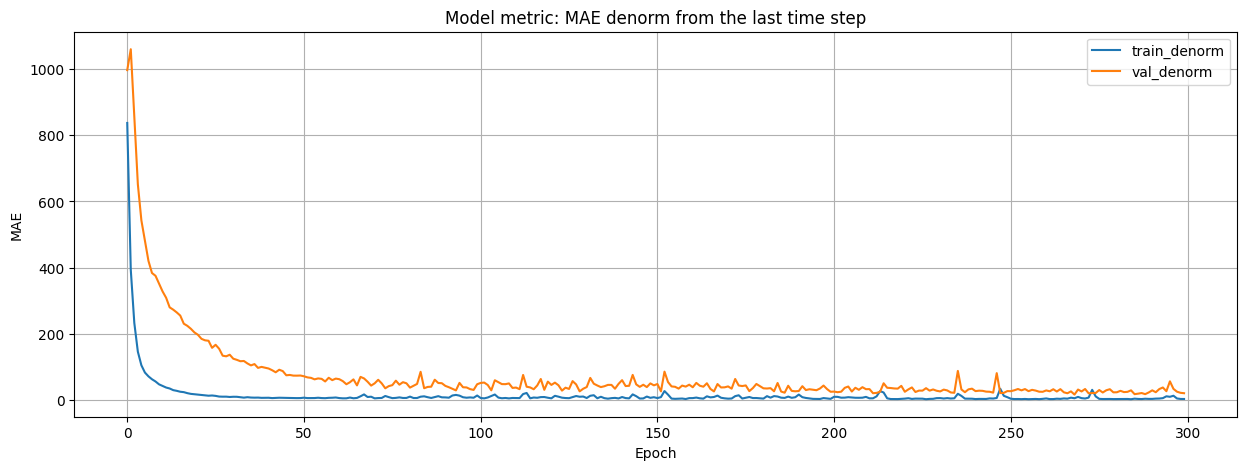

In [14]:
# Plot training & validation loss values
plt.figure(figsize=(15,5))
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss: mean squared error')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.grid()
plt.show()

# Plot training & validation laststep_mae values
plt.figure(figsize=(15,5))
plt.plot(hist.history['laststep_mae'])
plt.plot(hist.history['val_laststep_mae'])
plt.title('Model metric: MAE from the last time step')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.grid()
plt.show()

# Plot training & validation laststep_mae_denorm values
plt.figure(figsize=(15,5))
plt.plot(hist.history['laststep_mae_denorm'])
plt.plot(hist.history['val_laststep_mae_denorm'])
plt.title('Model metric: MAE denorm from the last time step')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['train_denorm', 'val_denorm'], loc='upper right')
plt.grid()
plt.show()

# 5. Evaluate the model

In [18]:
# Load the model from the best epoch (minimum val_loss)
import os
bestmodel_path = max( [ f for f in os.listdir(".") if f.startswith('RNN_ex5_bestmodel_') and f.endswith(".keras") ] )
print( f"The best model: {bestmodel_path}" )

my_rnn_best = keras.models.load_model(bestmodel_path, compile=True )

The best model: RNN_ex5_bestmodel_epoch269.keras


In [19]:
# Evaluate the model from the last epoch
score = my_rnn.evaluate( x_test_norm, y_test_norm, verbose=0, return_dict=True )
print( "Test results (model from the last epoch):", score )

# Evaluate the model from the best epoch
score = my_rnn_best.evaluate( x_test_norm, y_test_norm, verbose=0, return_dict=True )
print( "Test results (model from the best epoch):", score )

Test results (model from the last epoch): {'laststep_mae': 0.10587436705827713, 'laststep_mae_denorm': 146.7038116455078, 'loss': 0.022090455517172813}
Test results (model from the best epoch): {'laststep_mae': 0.10342986136674881, 'laststep_mae_denorm': 143.31658935546875, 'loss': 0.021195542067289352}


# 6. Inference

In [20]:
# Only choose results from the last time step
y_pred_norm = my_rnn.predict( x_test_norm )[ : , -1, : ]         # last-epoch model
y2_pred_norm = my_rnn_best.predict( x_test_norm ) [ : , -1, : ]  # best-epoch model

# Denormalize using training statistics
y_pred = (y_pred_norm * train_std) + train_mean
y2_pred = (y2_pred_norm * train_std) + train_mean

# Show prediction results for the first 20 data in the test set
for i in range( 20 ):
    print( f"x_test[{i}] = {x_test[i].reshape(-1)}" )
    print( f"y_test[{i}]'s last-time-step = {y_test[i][-1]}" )
    print( f"y_pred_last_epoch[{i}] = {y_pred[i]} =round=> {np.around(y_pred[i])}" )
    print( f"y_pred_best_epoch[{i}] = {y2_pred[i]} =round=> {np.around(y2_pred[i])}\n" )

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
x_test[0] = [1392 1394 1396 1398 1400]
y_test[0]'s last-time-step = [1402 1404 1406]
y_pred_last_epoch[0] = [1350.53803403 1334.41667706 1350.04645471] =round=> [1351. 1334. 1350.]
y_pred_best_epoch[0] = [1358.18691572 1341.86469839 1356.73431205] =round=> [1358. 1342. 1357.]

x_test[1] = [1394 1396 1398 1400 1402]
y_test[1]'s last-time-step = [1404 1406 1408]
y_pred_last_epoch[1] = [1352.16936378 1335.95980004 1351.64309641] =round=> [1352. 1336. 1352.]
y_pred_best_epoch[1] = [1359.79412902 1343.39031216 1358.30881947] =round=> [1360. 1343. 1358.]

x_test[2] = [1396 1398 1400 1402 1404]
y_test[2]'s last-time-step = [1406 1408 1410]
y_pred_last_epoch[2] = [1353.79970245 1337.5022623  1353.23940774] =round=> [1354. 1338. 1353.]
y_pred_best_epoch[2] = [1361.39803869 1344.91295267 1359.88002325] =round=> [1361. 1345. 1360.]

x_test[3] = [1398 1400 1402 1404 1406]
y_test[3]'s last-time-step = [1408 1410 1412]
y